In [ ]:
# Installing required libraries
!apt-get install -y highs
!pip install pulp

# Importing the necessary libraries for data analysis and DEA modelling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pulp
from pulp import *
from matplotlib.lines import Line2D

# Setting up the dataset manually from our collected annual report data
# Each row represents one DMU (bank-year observation)
data = {
    'Bank': ['Santander UK']*4 + ['Barclays UK']*4 + ['Nationwide']*4 +
            ['Lloyds']*4 + ['NatWest']*4 + ['HSBC']*4,
    'Year': [2022, 2023, 2024, 2025]*6,
    'Total_Deposits': [197313, 195149, 185775, 192331,
                       258000, 241100, 244200, 244600,
                       183175, 192334, 197896, 282095,
                       475300, 471400, 494000, 496500,
                       450300, 431400, 433500, 443000,
                       291816, 279188, 335378, 326050],
    'Operating_Expenses': [2370, 2485, 2577, 2494,
                           4327, 4415, 4329, 4882,
                           2234, 2323, 2549, 3550,
                           9759, 10823, 11601, 11966,
                           7687, 7996, 8149, 8262,
                           3832, 3707, 4310, 4017],
    'Net_Loans': [223840, 211222, 202929, 205966,
                  205100, 202800, 207700, 216500,
                  208066, 210782, 213440, 300889,
                  454900, 449700, 459900, 481100,
                  366300, 381400, 400300, 418900,
                  210500, 219867, 224867, 237859],
    'Total_Revenue': [5006, 5176, 4683, 4796,
                      7259, 7587, 8274, 8708,
                      3860, 4669, 4781, 7484,
                      18209, 18629, 18003, 19422,
                      13156, 14752, 14703, 16641,
                      7952, 10807, 9979, 10468]
}

df = pd.DataFrame(data)
df['DMU'] = df['Bank'] + ' ' + df['Year'].astype(str)
print("Dataset loaded successfully")
print(f"Total DMUs: {len(df)}")
print(df[['DMU', 'Total_Deposits', 'Operating_Expenses', 'Net_Loans', 'Total_Revenue']].to_string(index=False))

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
E: Unable to locate package highs
Dataset loaded successfully
Total DMUs: 24
              DMU  Total_Deposits  Operating_Expenses  Net_Loans  Total_Revenue
Santander UK 2022          197313                2370     223840           5006
Santander UK 2023          195149                2485     211222           5176
Santander UK 2024          185775                2577     202929           4683
Santander UK 2025          192331                2494     205966           4796
 Barclays UK 2022          258000                4327     205100           7259
 Barclays UK 2023          241100                4415     202800           7587
 Barclays UK 2024          244200                4329     207700           8274
 Barclays UK 2025          244600                4882     216500           8708
  Nationwide 2022          183175                2234     208066           3860
  Nationwide 2023         

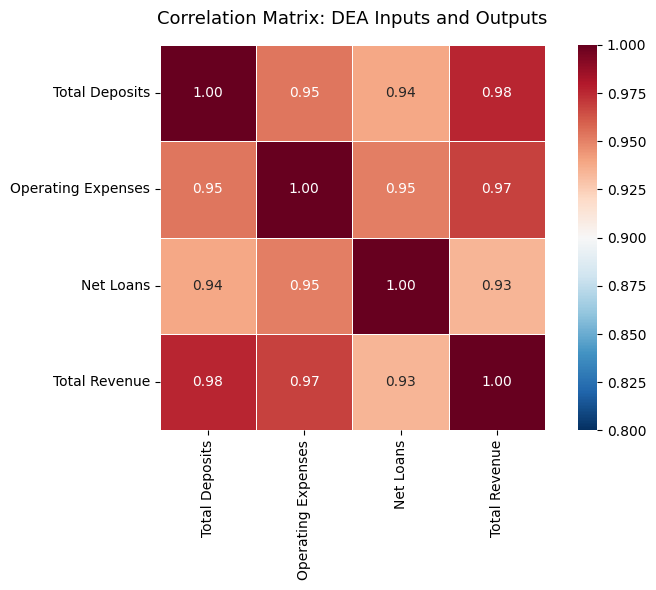

Input vs Input correlation:
Total Deposits vs Operating Expenses: 0.953

Input vs Output correlations (isotonicity check):
Total Deposits vs Net Loans: 0.939
Total Deposits vs Total Revenue: 0.976
Operating Expenses vs Net Loans: 0.951
Operating Expenses vs Total Revenue: 0.969

Output vs Output correlation:
Net Loans vs Total Revenue: 0.934


In [ ]:
# Checking correlations between all variables before running DEA
# We need to verify isotonicity - inputs and outputs should be positively correlated
# We also check for multicollinearity between inputs
variables = ['Total_Deposits', 'Operating_Expenses', 'Net_Loans', 'Total_Revenue']
labels    = ['Total Deposits', 'Operating Expenses', 'Net Loans', 'Total Revenue']

corr_matrix = df[variables].corr()
corr_matrix.index   = labels
corr_matrix.columns = labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=0.8, vmax=1.0, ax=ax, square=True, linewidths=0.5)
ax.set_title('Correlation Matrix: DEA Inputs and Outputs', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("Input vs Input correlation:")
print(f"Total Deposits vs Operating Expenses: {corr_matrix.iloc[0,1]:.3f}")
print()
print("Input vs Output correlations (isotonicity check):")
print(f"Total Deposits vs Net Loans: {corr_matrix.iloc[0,2]:.3f}")
print(f"Total Deposits vs Total Revenue: {corr_matrix.iloc[0,3]:.3f}")
print(f"Operating Expenses vs Net Loans: {corr_matrix.iloc[1,2]:.3f}")
print(f"Operating Expenses vs Total Revenue: {corr_matrix.iloc[1,3]:.3f}")
print()
print("Output vs Output correlation:")
print(f"Net Loans vs Total Revenue: {corr_matrix.iloc[2,3]:.3f}")

In [ ]:
# All three models use output orientation
# This means we ask how much each bank could expand its outputs
# while keeping its inputs fixed at their current levels
# Efficiency score = 1/phi, where phi >= 1
# A score of 1.0 means the bank is fully efficient
# A score below 1.0 means the bank could produce more output from the same inputs

# Output-oriented CRS (CCR) model
# Measures overall technical efficiency assuming constant returns to scale
def run_crs_dea(inputs, outputs, dmu_names):
    n = len(dmu_names)
    efficiency_scores = []

    for j in range(n):
        # Setting up the output-oriented LP for DMU j
        prob = LpProblem(f"CRS_DEA_{j}", LpMaximize)

        # Phi is the output expansion factor we are trying to maximise
        phi = LpVariable("phi", lowBound=1)

        # Lambda variables represent the peer weights
        lambdas = [LpVariable(f"lambda_{k}", lowBound=0) for k in range(n)]

        # Objective function - maximise phi
        prob += phi

        # Output constraints - virtual DMU must produce at least phi times the outputs
        for r in range(outputs.shape[1]):
            prob += lpSum(lambdas[k] * outputs[k, r] for k in range(n)) >= phi * outputs[j, r]

        # Input constraints - virtual DMU cannot use more inputs than DMU j
        for i in range(inputs.shape[1]):
            prob += lpSum(lambdas[k] * inputs[k, i] for k in range(n)) <= inputs[j, i]

        # Solving the LP using CBC solver
        prob.solve(PULP_CBC_CMD(msg=0))

        # Efficiency score is the inverse of phi for output orientation
        if value(phi) is not None:
            efficiency_scores.append(round(1 / value(phi), 4))
        else:
            print(f"Solver failed for DMU: {dmu_names[j]}")
            efficiency_scores.append(None)

    return efficiency_scores


# Output-oriented VRS (BCC) model
# Adds convexity constraint to isolate pure technical efficiency from scale effects
def run_vrs_dea(inputs, outputs, dmu_names):
    n = len(dmu_names)
    efficiency_scores = []

    for j in range(n):
        prob = LpProblem(f"VRS_DEA_{j}", LpMaximize)

        phi = LpVariable("phi", lowBound=1)
        lambdas = [LpVariable(f"lambda_{k}", lowBound=0) for k in range(n)]

        # Objective function - maximise phi
        prob += phi

        # Output constraints
        for r in range(outputs.shape[1]):
            prob += lpSum(lambdas[k] * outputs[k, r] for k in range(n)) >= phi * outputs[j, r]

        # Input constraints
        for i in range(inputs.shape[1]):
            prob += lpSum(lambdas[k] * inputs[k, i] for k in range(n)) <= inputs[j, i]

        # Convexity constraint - this is what distinguishes VRS from CRS
        prob += lpSum(lambdas[k] for k in range(n)) == 1

        # Solving the LP using CBC solver
        prob.solve(PULP_CBC_CMD(msg=0))

        # Efficiency score is the inverse of phi
        if value(phi) is not None:
            efficiency_scores.append(round(1 / value(phi), 4))
        else:
            print(f"Solver failed for DMU: {dmu_names[j]}")
            efficiency_scores.append(None)

    return efficiency_scores


# Output-oriented super efficiency model under VRS
# Excludes the DMU being evaluated from its own reference set
# Allows efficient banks to score above 1.0 so we can rank them
# Following Andersen and Petersen (1993)
def run_super_efficiency_vrs(inputs, outputs, vrs_scores):
    n = len(vrs_scores)
    super_scores = []

    for j in range(n):
        # Excluding DMU j from its own reference set
        peers = [k for k in range(n) if k != j]
        prob = LpProblem(f"SuperEff_VRS_{j}", LpMaximize)

        phi = LpVariable("phi", lowBound=0)
        lambdas = [LpVariable(f"lambda_{i}", lowBound=0) for i in range(len(peers))]

        # Objective function - maximise phi
        prob += phi

        # Output constraints excluding DMU j
        for r in range(outputs.shape[1]):
            prob += lpSum(lambdas[i] * outputs[peers[i], r] for i in range(len(peers))) >= phi * outputs[j, r]

        # Input constraints excluding DMU j
        for inp in range(inputs.shape[1]):
            prob += lpSum(lambdas[i] * inputs[peers[i], inp] for i in range(len(peers))) <= inputs[j, inp]

        # Convexity constraint excluding DMU j
        prob += lpSum(lambdas[i] for i in range(len(peers))) == 1

        # Solving the LP using CBC solver
        prob.solve(PULP_CBC_CMD(msg=0))

        # For super efficiency we keep phi directly
        # Converting back to efficiency score using 1/phi
        if value(phi) is not None:
            raw = value(phi)
            super_scores.append(round(1 / raw if raw > 0 else vrs_scores[j], 4))
        else:
            # If infeasible fall back to VRS score
            super_scores.append(vrs_scores[j])

    return super_scores

In [ ]:
# Extracting inputs and outputs as numpy arrays for the DEA functions
inputs    = df[['Total_Deposits', 'Operating_Expenses']].values.astype(float)
outputs   = df[['Net_Loans', 'Total_Revenue']].values.astype(float)
dmu_names = df['DMU'].tolist()

# Running the CRS model on all 24 DMUs
df['CRS_Efficiency'] = run_crs_dea(inputs, outputs, dmu_names)

# Printing CRS results
print("CRS MODEL RESULTS - OVERALL TECHNICAL EFFICIENCY")
print()
print("The CRS model assumes constant returns to scale.")
print("A score of 1.0 means the bank is fully efficient under this assumption.")
print("A score below 1.0 means the bank could expand its outputs proportionally")
print("to reach the efficiency frontier.")
print()
print(df[['DMU', 'Bank', 'Year', 'CRS_Efficiency']].to_string(index=False))
print()

# Bank level CRS averages
print("Average CRS Efficiency by Bank:")
crs_avg = df.groupby('Bank')['CRS_Efficiency'].mean().round(4).sort_values(ascending=False)
print(crs_avg.to_string())
print()

# Identifying fully efficient banks under CRS
crs_efficient = df[df['CRS_Efficiency'] >= 0.9999][['DMU', 'CRS_Efficiency']]
print(f"Banks on the CRS frontier: {len(crs_efficient)} out of {len(df)}")
print(crs_efficient.to_string(index=False))

CRS MODEL RESULTS - OVERALL TECHNICAL EFFICIENCY

The CRS model assumes constant returns to scale.
A score of 1.0 means the bank is fully efficient under this assumption.
A score below 1.0 means the bank could expand its outputs proportionally
to reach the efficiency frontier.

              DMU         Bank  Year  CRS_Efficiency
Santander UK 2022 Santander UK  2022          1.0000
Santander UK 2023 Santander UK  2023          0.9805
Santander UK 2024 Santander UK  2024          0.9694
Santander UK 2025 Santander UK  2025          0.9522
 Barclays UK 2022  Barclays UK  2022          0.8100
 Barclays UK 2023  Barclays UK  2023          0.8667
 Barclays UK 2024  Barclays UK  2024          0.9106
 Barclays UK 2025  Barclays UK  2025          0.9322
  Nationwide 2022   Nationwide  2022          1.0000
  Nationwide 2023   Nationwide  2023          0.9660
  Nationwide 2024   Nationwide  2024          0.9510
  Nationwide 2025   Nationwide  2025          0.9740
      Lloyds 2022       Lloyds  

In [ ]:
# Running the VRS model on all 24 DMUs
df['VRS_Efficiency'] = run_vrs_dea(inputs, outputs, dmu_names)

# Printing VRS results
print("VRS MODEL RESULTS - PURE TECHNICAL EFFICIENCY")
print()
print("The VRS model adds a convexity constraint to account for size differences.")
print("It isolates pure technical efficiency by removing scale effects.")
print("A bank can score 1.0 on VRS but still be scale inefficient.")
print()
print(df[['DMU', 'Bank', 'Year', 'CRS_Efficiency', 'VRS_Efficiency']].to_string(index=False))
print()

# Bank level VRS averages
print("Average VRS Efficiency by Bank:")
vrs_avg = df.groupby('Bank')['VRS_Efficiency'].mean().round(4).sort_values(ascending=False)
print(vrs_avg.to_string())
print()

# Identifying fully efficient banks under VRS
vrs_efficient = df[df['VRS_Efficiency'] >= 0.9999][['DMU', 'VRS_Efficiency']]
print(f"Banks on the VRS frontier: {len(vrs_efficient)} out of {len(df)}")
print(vrs_efficient.to_string(index=False))
print()

# Comparing CRS vs VRS to see where differences arise
print("Difference between VRS and CRS scores (positive means VRS > CRS):")
df['CRS_VRS_Diff'] = (df['VRS_Efficiency'] - df['CRS_Efficiency']).round(4)
print(df[['DMU', 'CRS_Efficiency', 'VRS_Efficiency', 'CRS_VRS_Diff']].to_string(index=False))

VRS MODEL RESULTS - PURE TECHNICAL EFFICIENCY

The VRS model adds a convexity constraint to account for size differences.
It isolates pure technical efficiency by removing scale effects.
A bank can score 1.0 on VRS but still be scale inefficient.

              DMU         Bank  Year  CRS_Efficiency  VRS_Efficiency
Santander UK 2022 Santander UK  2022          1.0000          1.0000
Santander UK 2023 Santander UK  2023          0.9805          1.0000
Santander UK 2024 Santander UK  2024          0.9694          1.0000
Santander UK 2025 Santander UK  2025          0.9522          0.9711
 Barclays UK 2022  Barclays UK  2022          0.8100          0.8305
 Barclays UK 2023  Barclays UK  2023          0.8667          0.9159
 Barclays UK 2024  Barclays UK  2024          0.9106          0.9607
 Barclays UK 2025  Barclays UK  2025          0.9322          1.0000
  Nationwide 2022   Nationwide  2022          1.0000          1.0000
  Nationwide 2023   Nationwide  2023          0.9660          

In [ ]:
# Calculating scale efficiency as the ratio of CRS to VRS
# A score of 1.0 means the bank is operating at its optimal scale
# A score below 1.0 means there is a scale-related inefficiency
df['Scale_Efficiency'] = (df['CRS_Efficiency'] / df['VRS_Efficiency']).round(4)

# Determining returns to scale for each DMU
# If scale efficiency = 1 the bank operates at constant returns to scale
# If scale efficiency < 1 the bank is either too large or too small
def get_returns_to_scale(row):
    if row['Scale_Efficiency'] >= 0.9999:
        return 'CRS - Optimal scale'
    else:
        return 'Non-optimal scale'

df['Returns_to_Scale'] = df.apply(get_returns_to_scale, axis=1)

# Printing scale efficiency results
print("SCALE EFFICIENCY RESULTS")
print()
print("Scale Efficiency = CRS / VRS")
print("A score of 1.0 means the bank is operating at its most productive scale size.")
print("A score below 1.0 means the bank could improve efficiency by changing its scale.")
print()
print(df[['DMU', 'Bank', 'Year', 'CRS_Efficiency', 'VRS_Efficiency',
          'Scale_Efficiency', 'Returns_to_Scale']].to_string(index=False))
print()

# Bank level scale efficiency averages
print("Average Scale Efficiency by Bank:")
scale_avg = df.groupby('Bank')['Scale_Efficiency'].mean().round(4).sort_values(ascending=False)
print(scale_avg.to_string())
print()

# Banks at optimal scale
optimal_scale = df[df['Scale_Efficiency'] >= 0.9999][['DMU', 'Scale_Efficiency']]
print(f"Banks at optimal scale: {len(optimal_scale)} out of {len(df)}")
print(optimal_scale.to_string(index=False))
print()

# Banks furthest from optimal scale
print("Banks furthest from optimal scale (lowest scale efficiency):")
worst_scale = df.nsmallest(5, 'Scale_Efficiency')[['DMU', 'CRS_Efficiency',
                                                    'VRS_Efficiency', 'Scale_Efficiency']]
print(worst_scale.to_string(index=False))

SCALE EFFICIENCY RESULTS

Scale Efficiency = CRS / VRS
A score of 1.0 means the bank is operating at its most productive scale size.
A score below 1.0 means the bank could improve efficiency by changing its scale.

              DMU         Bank  Year  CRS_Efficiency  VRS_Efficiency  Scale_Efficiency    Returns_to_Scale
Santander UK 2022 Santander UK  2022          1.0000          1.0000            1.0000 CRS - Optimal scale
Santander UK 2023 Santander UK  2023          0.9805          1.0000            0.9805   Non-optimal scale
Santander UK 2024 Santander UK  2024          0.9694          1.0000            0.9694   Non-optimal scale
Santander UK 2025 Santander UK  2025          0.9522          0.9711            0.9805   Non-optimal scale
 Barclays UK 2022  Barclays UK  2022          0.8100          0.8305            0.9753   Non-optimal scale
 Barclays UK 2023  Barclays UK  2023          0.8667          0.9159            0.9463   Non-optimal scale
 Barclays UK 2024  Barclays UK  2024

In [ ]:
# Running super efficiency under VRS
# This removes each DMU from its own reference set
# allowing efficient banks to score above 1.0 and be ranked
# Following Andersen and Petersen (1993)
df['Super_Efficiency'] = run_super_efficiency_vrs(inputs, outputs, df['VRS_Efficiency'].tolist())

# Flagging whether each DMU is on the efficient frontier
df['On_Frontier'] = df['VRS_Efficiency'].apply(lambda x: 'Yes' if x >= 0.9999 else 'No')

# Printing super efficiency results
print("SUPER EFFICIENCY RESULTS")
print()
print("Super efficiency allows banks scoring 1.0 on VRS to be ranked against each other.")
print("A score above 1.0 means the bank remains efficient even when excluded")
print("from its own reference set - it genuinely outperforms its peers.")
print("A score below 1.0 for non-frontier banks is the same as their VRS score.")
print()
print(df[['DMU', 'Bank', 'Year', 'VRS_Efficiency',
          'Super_Efficiency', 'On_Frontier']].to_string(index=False))
print()

# Ranking frontier banks by super efficiency
print("Frontier banks ranked by super efficiency (highest to lowest):")
frontier_ranked = df[df['On_Frontier'] == 'Yes'][['DMU', 'Bank', 'Year',
                                                    'Super_Efficiency']].sort_values(
                                                    'Super_Efficiency', ascending=False)
print(frontier_ranked.to_string(index=False))
print()

# Super efficiency outlier detection
# Using 1.5 standard deviations above the mean as the outlier threshold
super_mean = df['Super_Efficiency'].mean()
super_std  = df['Super_Efficiency'].std()
threshold  = 1.5
outlier_cutoff = super_mean + threshold * super_std

print("Super Efficiency Outlier Analysis:")
print(f"Mean super efficiency:    {super_mean:.4f}")
print(f"Standard deviation:       {super_std:.4f}")
print(f"Outlier threshold (1.5 SD): {outlier_cutoff:.4f}")
print()

df['Super_Outlier'] = df['Super_Efficiency'] > outlier_cutoff
outliers = df[df['Super_Outlier'] == True][['DMU', 'Bank', 'Year', 'Super_Efficiency']]

if len(outliers) > 0:
    print("Outliers detected:")
    print(outliers.to_string(index=False))
    print()
    for _, row in outliers.iterrows():
        print(f"Note: {row['DMU']} has a super efficiency score of {row['Super_Efficiency']:.4f}")
        if row['Bank'] == 'Nationwide' and row['Year'] == 2025:
            print("      This is likely driven by the Virgin Money acquisition completed")
            print("      in October 2024 which significantly inflated Nationwide's balance")
            print("      sheet and income figures. This result should be interpreted")
            print("      with caution and acknowledged as a data quality limitation.")
        else:
            print("      This DMU significantly outperforms its peers and warrants")
            print("      further investigation in the discussion section.")
else:
    print("No super efficiency outliers detected above the threshold.")

SUPER EFFICIENCY RESULTS

Super efficiency allows banks scoring 1.0 on VRS to be ranked against each other.
A score above 1.0 means the bank remains efficient even when excluded
from its own reference set - it genuinely outperforms its peers.
A score below 1.0 for non-frontier banks is the same as their VRS score.

              DMU         Bank  Year  VRS_Efficiency  Super_Efficiency On_Frontier
Santander UK 2022 Santander UK  2022          1.0000            1.0461         Yes
Santander UK 2023 Santander UK  2023          1.0000            1.0268         Yes
Santander UK 2024 Santander UK  2024          1.0000            1.1296         Yes
Santander UK 2025 Santander UK  2025          0.9711            0.9711          No
 Barclays UK 2022  Barclays UK  2022          0.8305            0.8305          No
 Barclays UK 2023  Barclays UK  2023          0.9159            0.9159          No
 Barclays UK 2024  Barclays UK  2024          0.9607            0.9607          No
 Barclays UK 2025  

In [ ]:
# Mann-Whitney U test to compare efficiency scores between groups
# Testing whether domestic and foreign-owned banks have significantly different
# VRS efficiency distributions
from scipy import stats

domestic_vrs = df[df['Group'] == 'Domestic']['VRS_Efficiency'].values
foreign_vrs  = df[df['Group'] == 'Foreign-owned']['VRS_Efficiency'].values

stat, p_value = stats.mannwhitneyu(domestic_vrs, foreign_vrs, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")
print()
if p_value < 0.05:
    print("The difference in VRS efficiency between domestic and foreign-owned banks")
    print("is statistically significant at the 5% level (p < 0.05).")
else:
    print("The difference in VRS efficiency between domestic and foreign-owned banks")
    print("is not statistically significant at the 5% level (p >= 0.05).")

Mann-Whitney U statistic: 87.5000
P-value: 0.3547

The difference in VRS efficiency between domestic and foreign-owned banks
is not statistically significant at the 5% level (p >= 0.05).


In [ ]:
# Running DEA separately for domestic and foreign-owned banks
# This compares efficiency within peer groups rather than across the full sample
domestic_banks = ['Lloyds', 'NatWest', 'Nationwide']
foreign_banks  = ['HSBC', 'Barclays UK', 'Santander UK']

df_domestic = df[df['Bank'].isin(domestic_banks)].reset_index(drop=True)
df_foreign  = df[df['Bank'].isin(foreign_banks)].reset_index(drop=True)

inputs_dom  = df_domestic[['Total_Deposits', 'Operating_Expenses']].values.astype(float)
outputs_dom = df_domestic[['Net_Loans', 'Total_Revenue']].values.astype(float)
inputs_for  = df_foreign[['Total_Deposits', 'Operating_Expenses']].values.astype(float)
outputs_for = df_foreign[['Net_Loans', 'Total_Revenue']].values.astype(float)

df_domestic['Group_CRS'] = run_crs_dea(inputs_dom, outputs_dom, df_domestic['DMU'].tolist())
df_domestic['Group_VRS'] = run_vrs_dea(inputs_dom, outputs_dom, df_domestic['DMU'].tolist())
df_foreign['Group_CRS']  = run_crs_dea(inputs_for, outputs_for, df_foreign['DMU'].tolist())
df_foreign['Group_VRS']  = run_vrs_dea(inputs_for, outputs_for, df_foreign['DMU'].tolist())

# Printing group comparison results
print("GROUP COMPARISON RESULTS")
print()
print("Domestic Banks (Lloyds, NatWest, Nationwide):")
print(df_domestic[['DMU', 'Group_CRS', 'Group_VRS']].to_string(index=False))
print()
print("Foreign-owned Banks (HSBC, Barclays UK, Santander UK):")
print(df_foreign[['DMU', 'Group_CRS', 'Group_VRS']].to_string(index=False))
print()

# Group averages
print("Group Average Scores:")
print(f"Domestic     - Average CRS: {df_domestic['Group_CRS'].mean():.4f}   Average VRS: {df_domestic['Group_VRS'].mean():.4f}")
print(f"Foreign-owned - Average CRS: {df_foreign['Group_CRS'].mean():.4f}   Average VRS: {df_foreign['Group_VRS'].mean():.4f}")
print()

# Identifying which group is more efficient
dom_vrs_avg = df_domestic['Group_VRS'].mean()
for_vrs_avg = df_foreign['Group_VRS'].mean()
if dom_vrs_avg > for_vrs_avg:
    print(f"Domestic banks are on average more efficient than foreign-owned banks")
    print(f"by a margin of {dom_vrs_avg - for_vrs_avg:.4f} on the VRS score.")
elif for_vrs_avg > dom_vrs_avg:
    print(f"Foreign-owned banks are on average more efficient than domestic banks")
    print(f"by a margin of {for_vrs_avg - dom_vrs_avg:.4f} on the VRS score.")
else:
    print("Both groups show equal average VRS efficiency.")

GROUP COMPARISON RESULTS

Domestic Banks (Lloyds, NatWest, Nationwide):
            DMU  Group_CRS  Group_VRS
Nationwide 2022     1.0000     1.0000
Nationwide 2023     1.0000     1.0000
Nationwide 2024     0.9839     0.9840
Nationwide 2025     1.0000     1.0000
    Lloyds 2022     1.0000     1.0000
    Lloyds 2023     1.0000     1.0000
    Lloyds 2024     0.9530     0.9646
    Lloyds 2025     1.0000     1.0000
   NatWest 2022     0.8422     0.9056
   NatWest 2023     0.9255     0.9256
   NatWest 2024     0.9444     0.9631
   NatWest 2025     1.0000     1.0000

Foreign-owned Banks (HSBC, Barclays UK, Santander UK):
              DMU  Group_CRS  Group_VRS
Santander UK 2022     1.0000     1.0000
Santander UK 2023     0.9869     1.0000
Santander UK 2024     0.9737     1.0000
Santander UK 2025     0.9577     0.9711
 Barclays UK 2022     0.8463     0.9004
 Barclays UK 2023     0.9182     0.9219
 Barclays UK 2024     0.9590     0.9607
 Barclays UK 2025     1.0000     1.0000
        HSBC 2022 

In [ ]:
# Comprehensive summary table combining all model results
# This is the main table to include in the report

print("FINAL SUMMARY TABLE - ALL MODELS AND ALL DMUs")
print()

# Building the complete summary table
summary_table = df[['DMU', 'Bank', 'Year',
                     'CRS_Efficiency', 'VRS_Efficiency',
                     'Scale_Efficiency', 'Super_Efficiency',
                     'Returns_to_Scale', 'On_Frontier']].copy()
summary_table = summary_table.sort_values(['Bank', 'Year']).reset_index(drop=True)
print(summary_table.to_string(index=False))
print()

# Bank level averages across all four years
print("BANK-LEVEL AVERAGE SCORES ACROSS ALL YEARS")
print()
bank_summary = df.groupby('Bank').agg(
    Avg_CRS           = ('CRS_Efficiency',   'mean'),
    Avg_VRS           = ('VRS_Efficiency',   'mean'),
    Avg_Scale         = ('Scale_Efficiency', 'mean'),
    Avg_Super         = ('Super_Efficiency', 'mean'),
    Years_on_Frontier = ('On_Frontier', lambda x: (x == 'Yes').sum())
).round(4)
bank_summary = bank_summary.sort_values('Avg_VRS', ascending=False)
print(bank_summary.to_string())
print()

# Group level summary
print("GROUP LEVEL SUMMARY")
print()
df['Group'] = df['Bank'].apply(lambda x: 'Domestic' if x in domestic_banks else 'Foreign-owned')
group_summary = df.groupby('Group').agg(
    Avg_CRS           = ('CRS_Efficiency',   'mean'),
    Avg_VRS           = ('VRS_Efficiency',   'mean'),
    Avg_Scale         = ('Scale_Efficiency', 'mean'),
    Avg_Super         = ('Super_Efficiency', 'mean'),
    Years_on_Frontier = ('On_Frontier', lambda x: (x == 'Yes').sum())
).round(4)
print(group_summary.to_string())
print()

# Inefficient banks and required output expansion
print("INEFFICIENT BANKS - OUTPUT EXPANSION NEEDED TO REACH FRONTIER")
print()
inefficient = df[df['On_Frontier'] == 'No'][['DMU', 'Bank', 'Year',
                                              'VRS_Efficiency']].copy()
inefficient['Output_Gap_%'] = ((1 / inefficient['VRS_Efficiency'] - 1) * 100).round(2)
inefficient = inefficient.sort_values('Output_Gap_%', ascending=False)
print(inefficient.to_string(index=False))
print()

# Overall descriptive statistics
print("OVERALL DESCRIPTIVE STATISTICS ACROSS ALL 24 DMUs")
print()
stats = df[['CRS_Efficiency', 'VRS_Efficiency',
            'Scale_Efficiency', 'Super_Efficiency']].describe().round(4)
print(stats.to_string())
print()

# Nationwide 2025 acquisition warning
print("IMPORTANT NOTE:")
print("Nationwide 2025 figures reflect the post-acquisition consolidated balance")
print("sheet following the completion of the Virgin Money acquisition in October 2024.")
print("These figures are not directly comparable to Nationwide 2022-2024 and should")
print("be interpreted with caution throughout all model results.")

FINAL SUMMARY TABLE - ALL MODELS AND ALL DMUs

              DMU         Bank  Year  CRS_Efficiency  VRS_Efficiency  Scale_Efficiency  Super_Efficiency    Returns_to_Scale On_Frontier
 Barclays UK 2022  Barclays UK  2022          0.8100          0.8305            0.9753            0.8305   Non-optimal scale          No
 Barclays UK 2023  Barclays UK  2023          0.8667          0.9159            0.9463            0.9159   Non-optimal scale          No
 Barclays UK 2024  Barclays UK  2024          0.9106          0.9607            0.9479            0.9607   Non-optimal scale          No
 Barclays UK 2025  Barclays UK  2025          0.9322          1.0000            0.9322            1.0197   Non-optimal scale         Yes
        HSBC 2022         HSBC  2022          0.7942          0.8133            0.9765            0.8133   Non-optimal scale          No
        HSBC 2023         HSBC  2023          1.0000          1.0000            1.0000            1.2305 CRS - Optimal scale       

In [ ]:
# Identifying super efficiency outliers
# An outlier is defined as a DMU whose super efficiency score deviates significantly
# from the group mean - we use 1.5 standard deviations as the threshold
# This is important because outliers can distort the efficiency frontier
# and may reflect structural anomalies rather than genuine efficiency

super_mean = df['Super_Efficiency'].mean()
super_std  = df['Super_Efficiency'].std()
threshold  = 1.5

print("Super Efficiency Outlier Analysis")
print(f"Mean super efficiency score: {super_mean:.4f}")
print(f"Standard deviation: {super_std:.4f}")
print(f"Outlier threshold: mean + {threshold} x std = {super_mean + threshold * super_std:.4f}")
print()

# Flagging DMUs that exceed the outlier threshold
df['Super_Outlier'] = df['Super_Efficiency'] > (super_mean + threshold * super_std)

outliers = df[df['Super_Outlier'] == True][['DMU', 'Bank', 'Year', 'CRS_Efficiency',
                                             'VRS_Efficiency', 'Scale_Efficiency',
                                             'Super_Efficiency']]

if len(outliers) > 0:
    print("Outliers detected:")
    print(outliers.to_string(index=False))
    print()
    for _, row in outliers.iterrows():
        print(f"Note: {row['DMU']} has a super efficiency score of {row['Super_Efficiency']:.4f}")
        if row['Bank'] == 'Nationwide' and row['Year'] == 2025:
            print("      This is likely driven by the Virgin Money acquisition completed")
            print("      in October 2024 which significantly inflated Nationwide's balance")
            print("      sheet and income figures and should be interpreted with caution.")
        else:
            print(f"      This DMU significantly outperforms its peers and warrants further investigation.")
else:
    print("No super efficiency outliers detected above the threshold.")

print()
print("Full super efficiency ranking (highest to lowest):")
print(df[['DMU', 'Super_Efficiency']].sort_values('Super_Efficiency', ascending=False).to_string(index=False))

Super Efficiency Outlier Analysis
Mean super efficiency score: 0.9932
Standard deviation: 0.0948
Outlier threshold: mean + 1.5 x std = 1.1354

Outliers detected:
            DMU       Bank  Year  CRS_Efficiency  VRS_Efficiency  Scale_Efficiency  Super_Efficiency
Nationwide 2025 Nationwide  2025           0.974             1.0             0.974            1.1445
      HSBC 2023       HSBC  2023           1.000             1.0             1.000            1.2305

Note: Nationwide 2025 has a super efficiency score of 1.1445
      This is likely driven by the Virgin Money acquisition completed
      in October 2024 which significantly inflated Nationwide's balance
      sheet and income figures and should be interpreted with caution.
Note: HSBC 2023 has a super efficiency score of 1.2305
      This DMU significantly outperforms its peers and warrants further investigation.

Full super efficiency ranking (highest to lowest):
              DMU  Super_Efficiency
        HSBC 2023            1

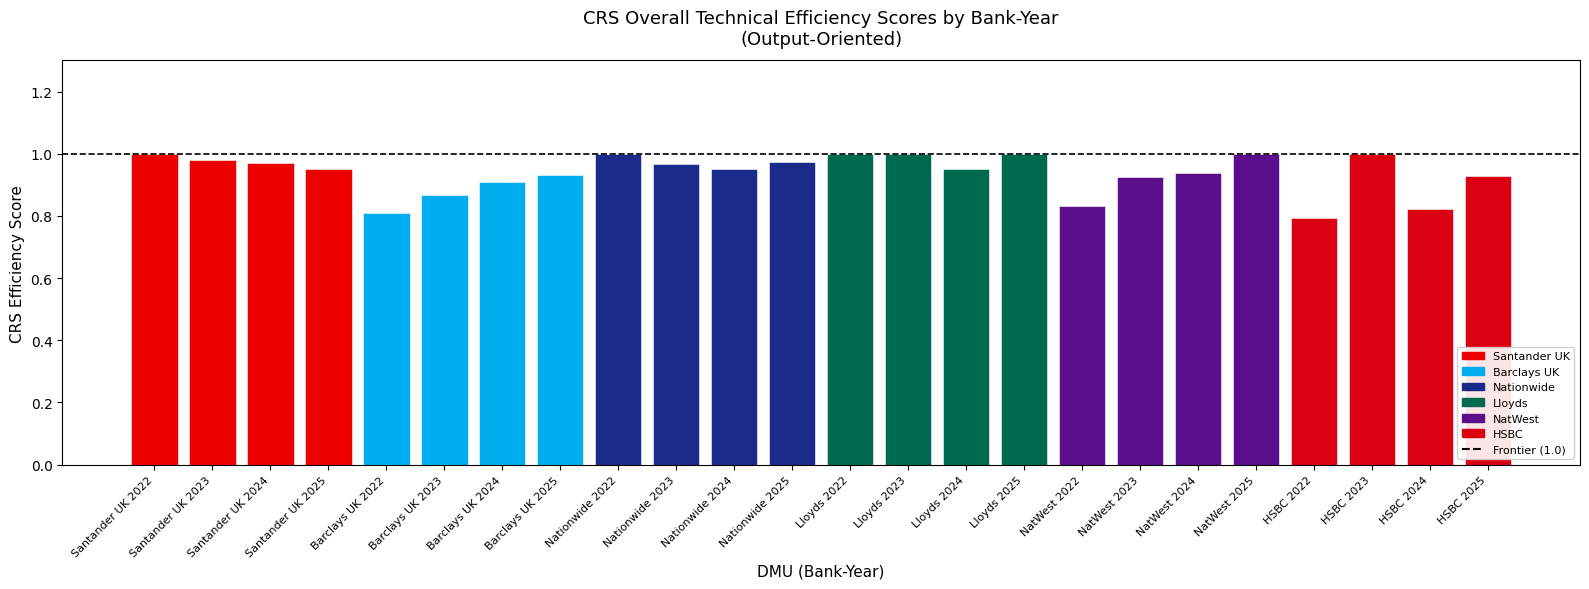

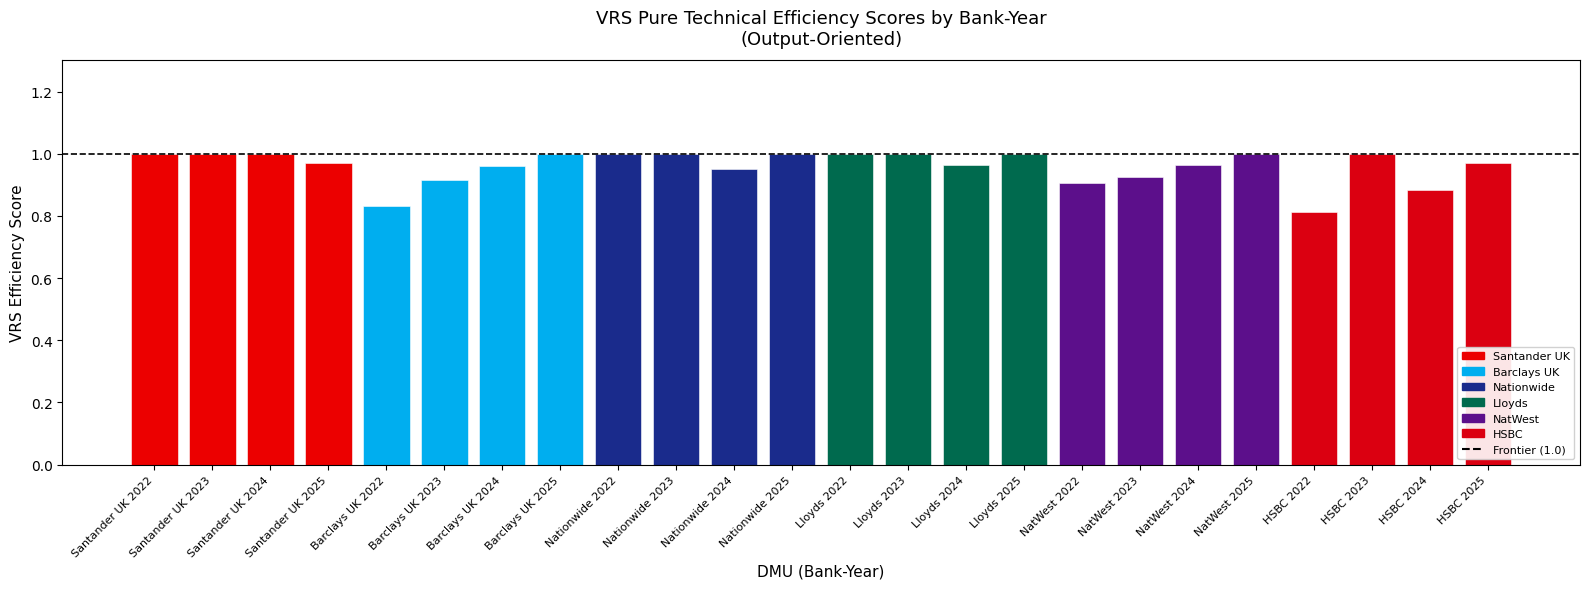

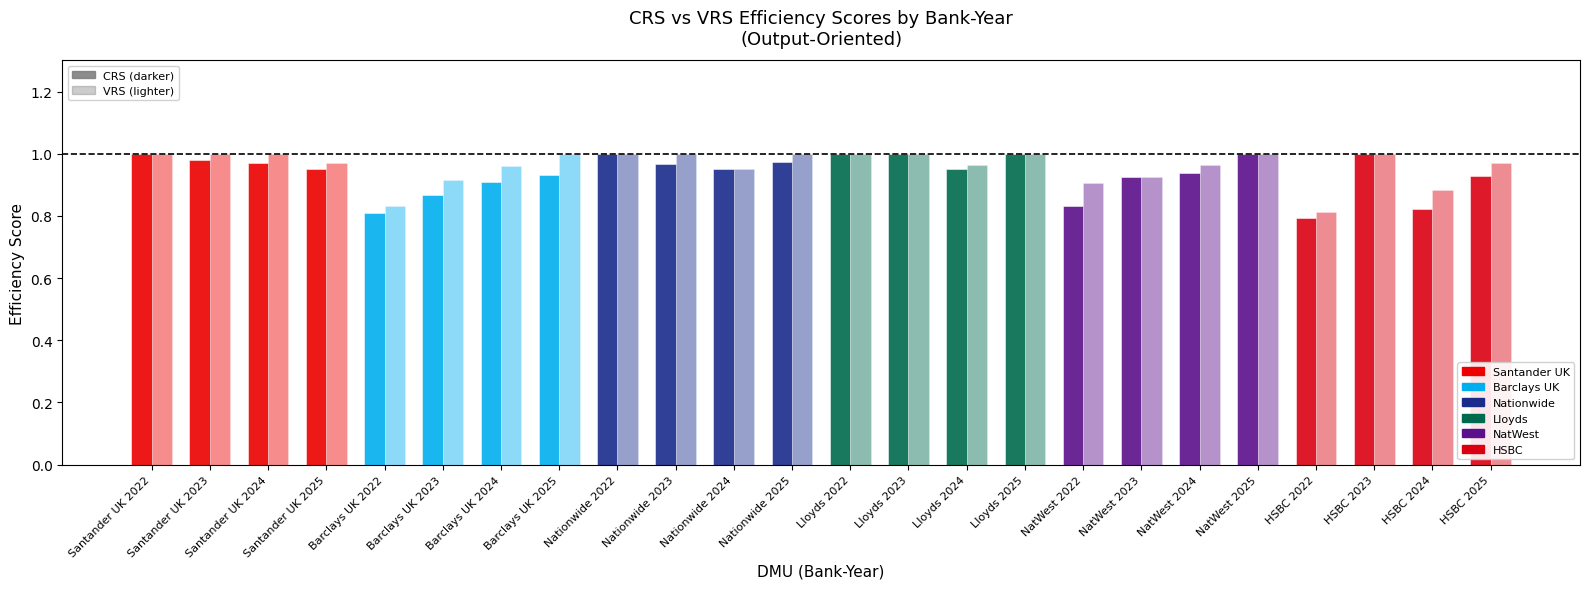

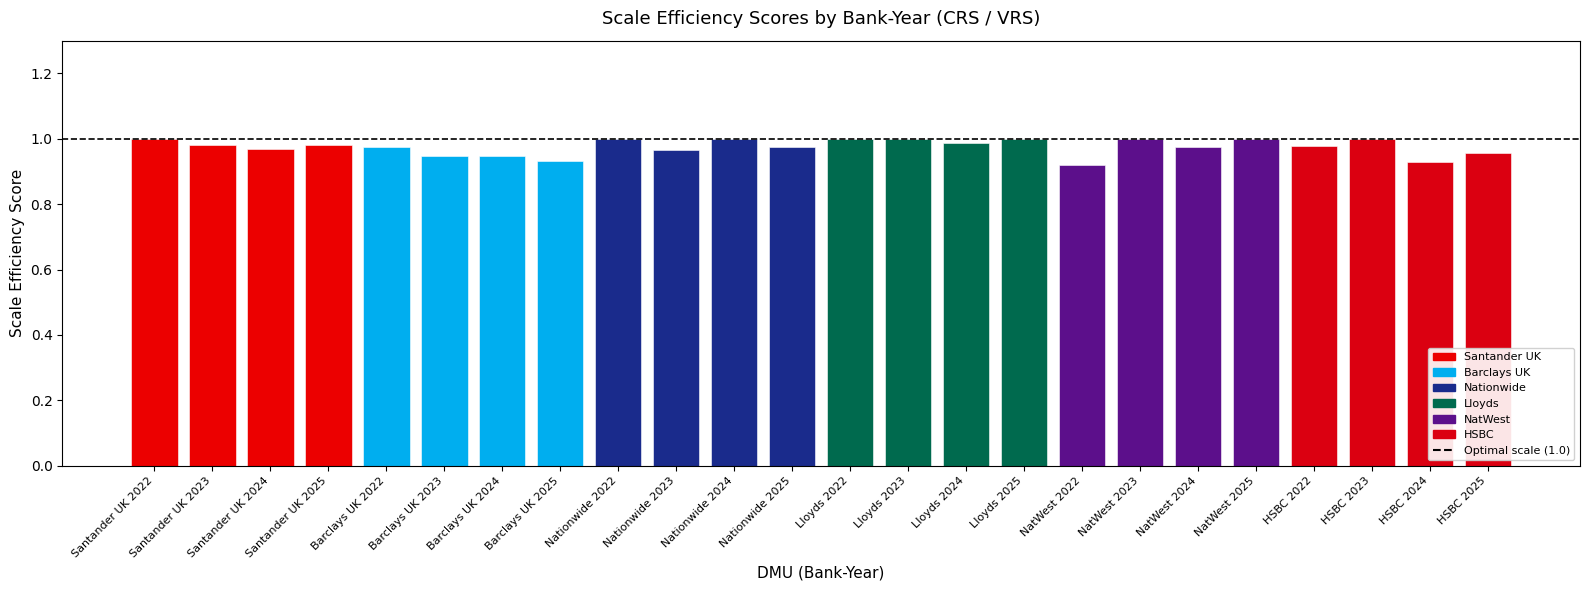

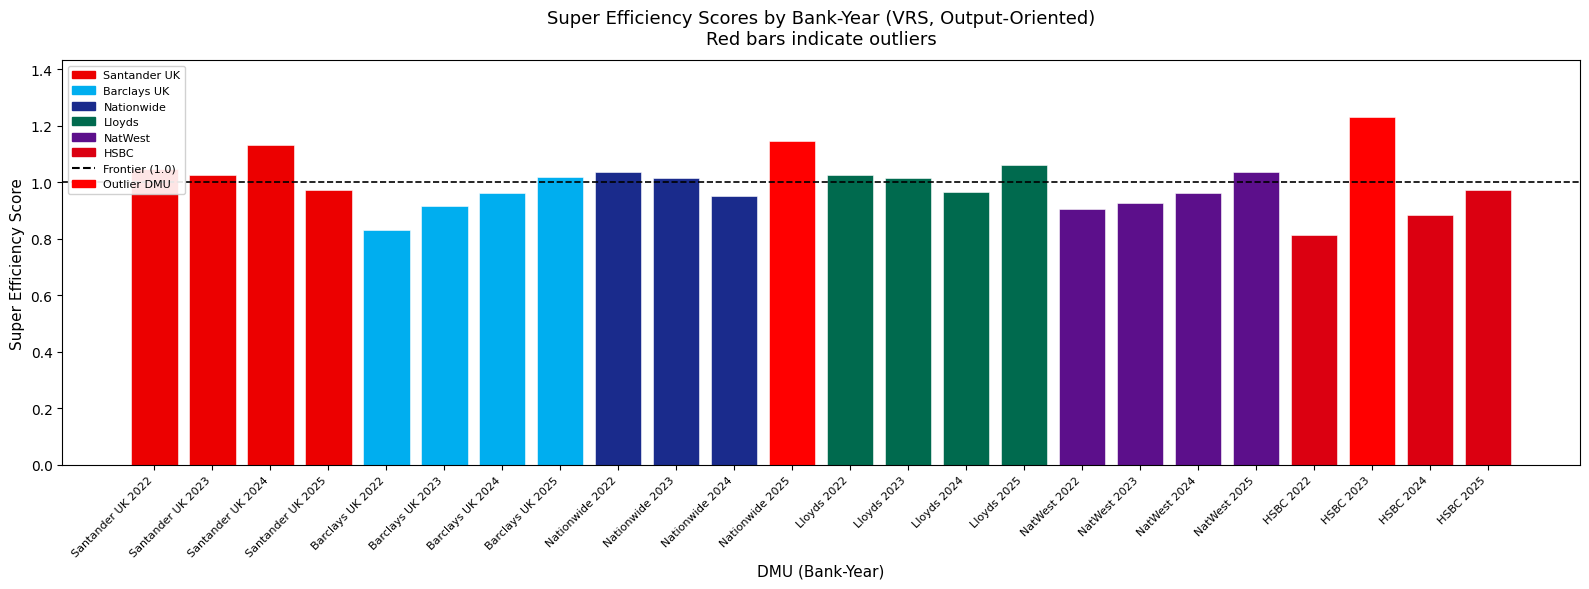

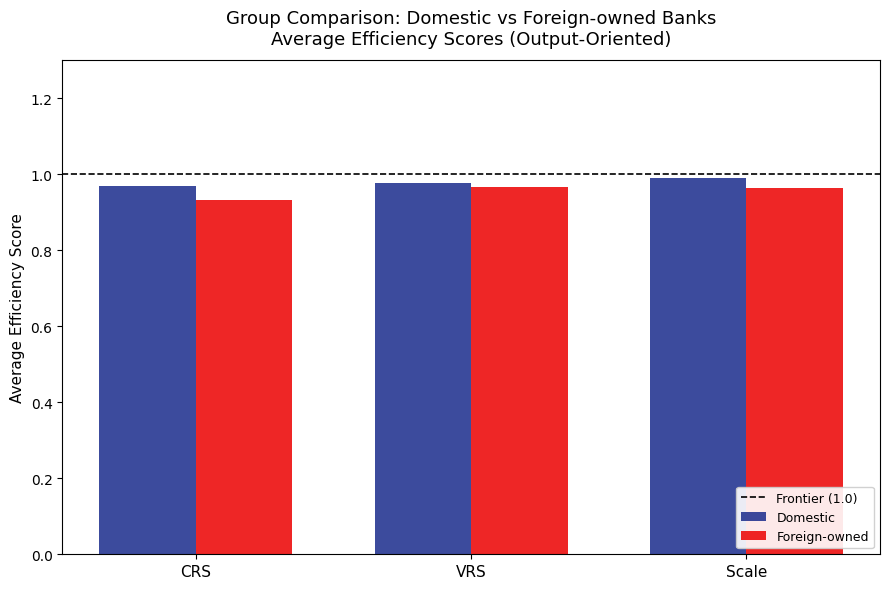

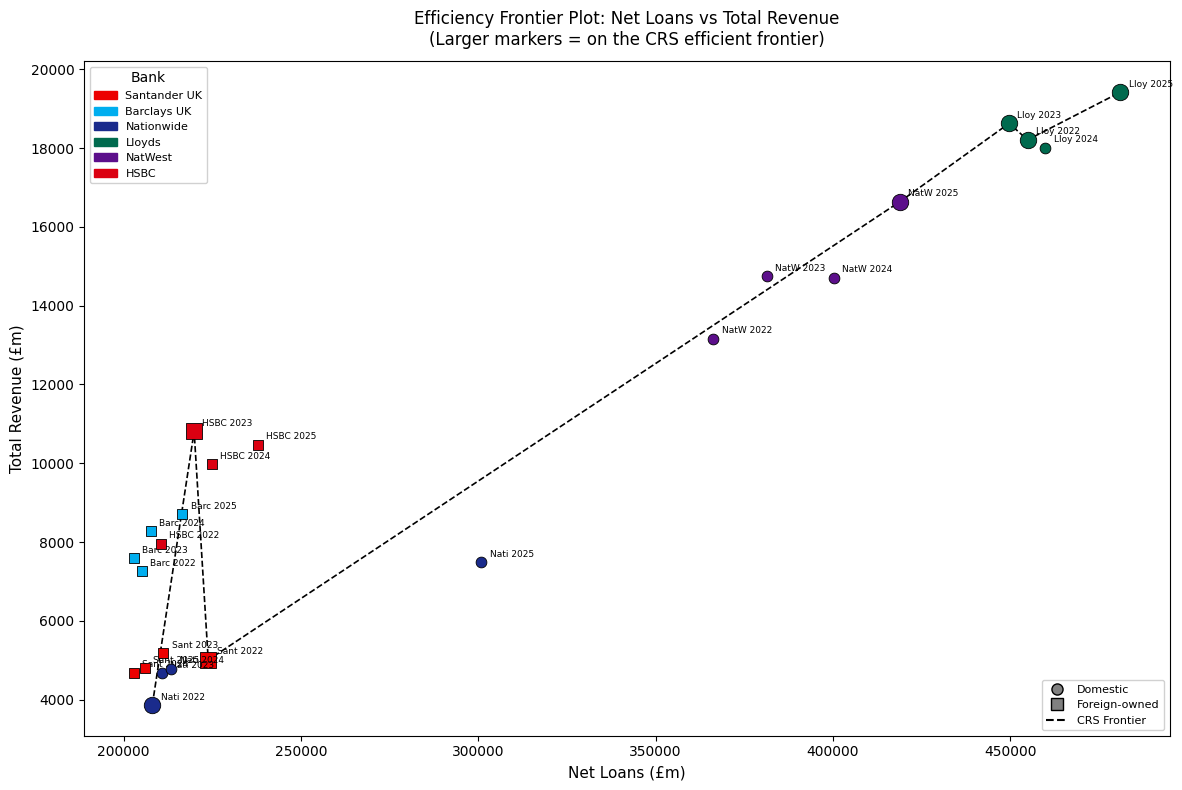

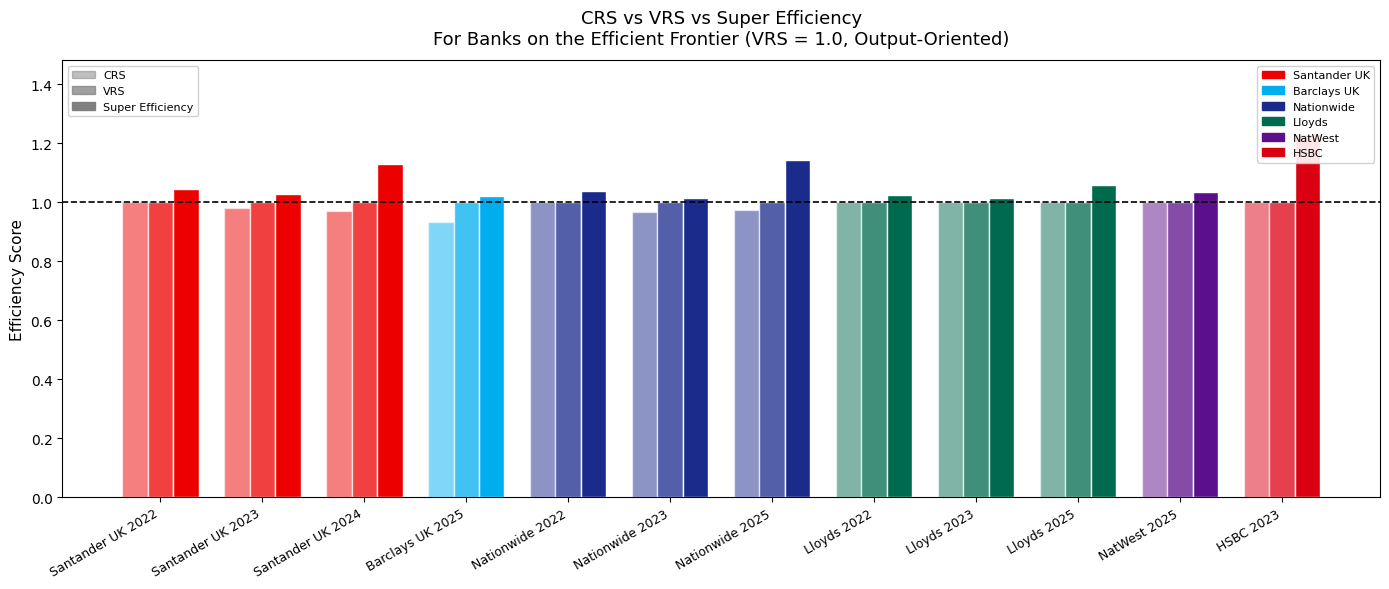

In [ ]:
# All visualisations using bank brand colours
bank_colours = {
    'Santander UK': '#EC0000',
    'Barclays UK':  '#00AEEF',
    'Nationwide':   '#1A2B8C',
    'Lloyds':       '#006A4E',
    'NatWest':      '#5C0F8B',
    'HSBC':         '#DB0011'
}

dmu_colours    = [bank_colours[b] for b in df['Bank']]
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in bank_colours.items()]
x_pos          = np.arange(len(df))
dmu_labels     = df['DMU'].tolist()

# Chart 1 - CRS efficiency scores
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos, df['CRS_Efficiency'], color=dmu_colours, edgecolor='white', linewidth=0.4)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(dmu_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('DMU (Bank-Year)', fontsize=11)
ax.set_ylabel('CRS Efficiency Score', fontsize=11)
ax.set_title('CRS Overall Technical Efficiency Scores by Bank-Year\n(Output-Oriented)', fontsize=13, pad=12)
ax.set_ylim(0, 1.3)
ax.legend(handles=legend_patches + [Line2D([0],[0], color='black', linestyle='--', label='Frontier (1.0)')],
          loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('crs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2 - VRS efficiency scores
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos, df['VRS_Efficiency'], color=dmu_colours, edgecolor='white', linewidth=0.4)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(dmu_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('DMU (Bank-Year)', fontsize=11)
ax.set_ylabel('VRS Efficiency Score', fontsize=11)
ax.set_title('VRS Pure Technical Efficiency Scores by Bank-Year\n(Output-Oriented)', fontsize=13, pad=12)
ax.set_ylim(0, 1.3)
ax.legend(handles=legend_patches + [Line2D([0],[0], color='black', linestyle='--', label='Frontier (1.0)')],
          loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('vrs_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3 - CRS vs VRS side by side
fig, ax = plt.subplots(figsize=(16, 6))
width = 0.35
ax.bar(x_pos - width/2, df['CRS_Efficiency'], width, color=dmu_colours,
       edgecolor='white', linewidth=0.4, alpha=0.9)
ax.bar(x_pos + width/2, df['VRS_Efficiency'], width, color=dmu_colours,
       edgecolor='white', linewidth=0.4, alpha=0.45)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(dmu_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('DMU (Bank-Year)', fontsize=11)
ax.set_ylabel('Efficiency Score', fontsize=11)
ax.set_title('CRS vs VRS Efficiency Scores by Bank-Year\n(Output-Oriented)', fontsize=13, pad=12)
ax.set_ylim(0, 1.3)
pattern_leg = [mpatches.Patch(color='grey', alpha=0.9, label='CRS (darker)'),
               mpatches.Patch(color='grey', alpha=0.4, label='VRS (lighter)')]
l1 = ax.legend(handles=pattern_leg, loc='upper left',
               bbox_to_anchor=(0.0, 1.0), fontsize=8, framealpha=0.9)
ax.add_artist(l1)
ax.legend(handles=legend_patches, loc='lower right',
          bbox_to_anchor=(1.0, 0.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('crs_vs_vrs.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 4 - Scale efficiency
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x_pos, df['Scale_Efficiency'], color=dmu_colours, edgecolor='white', linewidth=0.4)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(dmu_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('DMU (Bank-Year)', fontsize=11)
ax.set_ylabel('Scale Efficiency Score', fontsize=11)
ax.set_title('Scale Efficiency Scores by Bank-Year (CRS / VRS)', fontsize=13, pad=12)
ax.set_ylim(0, 1.3)
ax.legend(handles=legend_patches + [Line2D([0],[0], color='black', linestyle='--', label='Optimal scale (1.0)')],
          loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('scale_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 5 - Super efficiency
fig, ax = plt.subplots(figsize=(16, 6))
bar_colours_outlier = ['red' if o else c for o, c in zip(df['Super_Outlier'], dmu_colours)]
ax.bar(x_pos, df['Super_Efficiency'], color=bar_colours_outlier, edgecolor='white', linewidth=0.4)
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
ax.set_xticks(x_pos)
ax.set_xticklabels(dmu_labels, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('DMU (Bank-Year)', fontsize=11)
ax.set_ylabel('Super Efficiency Score', fontsize=11)
ax.set_title('Super Efficiency Scores by Bank-Year (VRS, Output-Oriented)\nRed bars indicate outliers', fontsize=13, pad=12)
ax.set_ylim(0, max(df['Super_Efficiency']) + 0.2)
outlier_patch = mpatches.Patch(color='red', label='Outlier DMU')
ax.legend(handles=legend_patches + [Line2D([0],[0], color='black', linestyle='--', label='Frontier (1.0)'), outlier_patch],
          loc='upper left', bbox_to_anchor=(0.0, 1.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('super_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 6 - Group comparison
categories = ['CRS', 'VRS', 'Scale']
dom_avgs = [df_domestic['Group_CRS'].mean(),
            df_domestic['Group_VRS'].mean(),
            (df_domestic['Group_CRS'] / df_domestic['Group_VRS']).mean()]
for_avgs = [df_foreign['Group_CRS'].mean(),
            df_foreign['Group_VRS'].mean(),
            (df_foreign['Group_CRS'] / df_foreign['Group_VRS']).mean()]
x_grp = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x_grp - width/2, dom_avgs, width, color='#1A2B8C', alpha=0.85, label='Domestic')
ax.bar(x_grp + width/2, for_avgs, width, color='#EC0000', alpha=0.85, label='Foreign-owned')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2, label='Frontier (1.0)')
ax.set_xticks(x_grp)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylabel('Average Efficiency Score', fontsize=11)
ax.set_title('Group Comparison: Domestic vs Foreign-owned Banks\nAverage Efficiency Scores (Output-Oriented)', fontsize=13, pad=12)
ax.set_ylim(0, 1.3)
ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0), fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('group_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 7 - Efficiency frontier scatter plot
fig, ax = plt.subplots(figsize=(12, 8))
for i, row in df.iterrows():
    colour = bank_colours[row['Bank']]
    marker = 'o' if row['Bank'] in domestic_banks else 's'
    size   = 140 if row['CRS_Efficiency'] >= 1.0 else 60
    ax.scatter(row['Net_Loans'], row['Total_Revenue'], color=colour, marker=marker,
               s=size, edgecolors='black', linewidth=0.6, zorder=3)
    ax.annotate(f"{row['Bank'][:4]} {row['Year']}", (row['Net_Loans'], row['Total_Revenue']),
                textcoords='offset points', xytext=(6, 4), fontsize=6.5)
frontier_df = df[df['CRS_Efficiency'] >= 0.9999].sort_values('Net_Loans')
if len(frontier_df) > 1:
    ax.plot(frontier_df['Net_Loans'], frontier_df['Total_Revenue'],
            color='black', linestyle='--', linewidth=1.2, zorder=2)
ax.set_xlabel('Net Loans (£m)', fontsize=11)
ax.set_ylabel('Total Revenue (£m)', fontsize=11)
ax.set_title('Efficiency Frontier Plot: Net Loans vs Total Revenue\n(Larger markers = on the CRS efficient frontier)',
             fontsize=12, pad=12)
colour_leg = [mpatches.Patch(color=v, label=k) for k, v in bank_colours.items()]
shape_leg  = [Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
                      markersize=8, markeredgecolor='black', label='Domestic'),
              Line2D([0],[0], marker='s', color='w', markerfacecolor='grey',
                      markersize=8, markeredgecolor='black', label='Foreign-owned'),
              Line2D([0],[0], color='black', linestyle='--', label='CRS Frontier')]
l1 = ax.legend(handles=colour_leg, loc='upper left',
               bbox_to_anchor=(0.0, 1.0), fontsize=8, framealpha=0.9, title='Bank')
ax.add_artist(l1)
ax.legend(handles=shape_leg, loc='lower right',
          bbox_to_anchor=(1.0, 0.0), fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.savefig('efficiency_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 8 - CRS vs VRS vs Super efficiency for frontier banks only
frontier_banks_df = df[df['VRS_Efficiency'] >= 0.9999].copy()
if len(frontier_banks_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    x_fr   = np.arange(len(frontier_banks_df))
    width  = 0.25
    f_col  = [bank_colours[b] for b in frontier_banks_df['Bank']]
    ax.bar(x_fr - width, frontier_banks_df['CRS_Efficiency'],   width, color=f_col, alpha=0.5,  edgecolor='white')
    ax.bar(x_fr,         frontier_banks_df['VRS_Efficiency'],   width, color=f_col, alpha=0.75, edgecolor='white')
    ax.bar(x_fr + width, frontier_banks_df['Super_Efficiency'], width, color=f_col, alpha=1.0,  edgecolor='white')
    ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1.2)
    ax.set_xticks(x_fr)
    ax.set_xticklabels(frontier_banks_df['DMU'], rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Efficiency Score', fontsize=11)
    ax.set_title('CRS vs VRS vs Super Efficiency\nFor Banks on the Efficient Frontier (VRS = 1.0, Output-Oriented)', fontsize=13, pad=12)
    ax.set_ylim(0, max(frontier_banks_df['Super_Efficiency']) + 0.25)
    pat_leg = [mpatches.Patch(color='grey', alpha=0.5,  label='CRS'),
               mpatches.Patch(color='grey', alpha=0.75, label='VRS'),
               mpatches.Patch(color='grey', alpha=1.0,  label='Super Efficiency')]
    present_banks = frontier_banks_df['Bank'].unique()
    col_leg = [mpatches.Patch(color=bank_colours[b], label=b) for b in present_banks]
    l1 = ax.legend(handles=pat_leg, loc='upper left',
                   bbox_to_anchor=(0.0, 1.0), fontsize=8, framealpha=0.9)
    ax.add_artist(l1)
    ax.legend(handles=col_leg, loc='upper right',
              bbox_to_anchor=(1.0, 1.0), fontsize=8, framealpha=0.9)
    plt.tight_layout()
    plt.savefig('frontier_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()



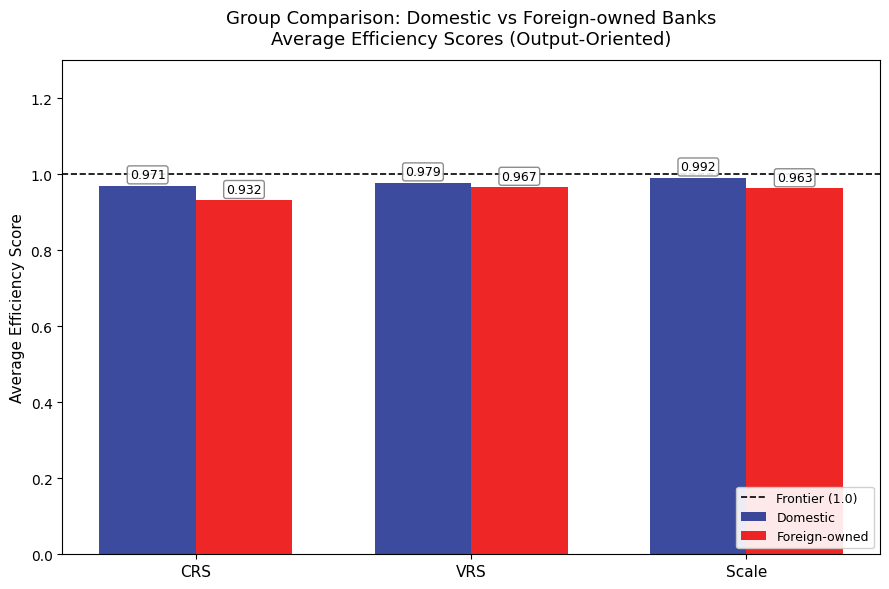

In [ ]:
# Chart 6 - Group comparison
categories = ['CRS', 'VRS', 'Scale']

dom_avgs = [
    df_domestic['Group_CRS'].mean(),
    df_domestic['Group_VRS'].mean(),
    (df_domestic['Group_CRS'] / df_domestic['Group_VRS']).mean()
]

for_avgs = [
    df_foreign['Group_CRS'].mean(),
    df_foreign['Group_VRS'].mean(),
    (df_foreign['Group_CRS'] / df_foreign['Group_VRS']).mean()
]

x_grp = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))

bars1 = ax.bar(
    x_grp - width/2,
    dom_avgs,
    width,
    color='#1A2B8C',
    alpha=0.85,
    label='Domestic'
)

bars2 = ax.bar(
    x_grp + width/2,
    for_avgs,
    width,
    color='#EC0000',
    alpha=0.85,
    label='Foreign-owned'
)

# Add value labels on top of bars
ax.bar_label(
    bars1,
    fmt='%.3f',
    padding=3,
    fontsize=9,
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        boxstyle='round,pad=0.2',
        alpha=0.9
    )
)
ax.bar_label(
    bars2,
    fmt='%.3f',
    padding=3,
    fontsize=9,
    bbox=dict(
        facecolor='white',
        edgecolor='gray',
        boxstyle='round,pad=0.2',
        alpha=0.9
    )
)

ax.axhline(
    y=1.0,
    color='black',
    linestyle='--',
    linewidth=1.2,
    label='Frontier (1.0)'
)

ax.set_xticks(x_grp)
ax.set_xticklabels(categories, fontsize=11)

ax.set_ylabel('Average Efficiency Score', fontsize=11)

ax.set_title(
    'Group Comparison: Domestic vs Foreign-owned Banks\nAverage Efficiency Scores (Output-Oriented)',
    fontsize=13,
    pad=12
)

ax.set_ylim(0, 1.3)

ax.legend(
    loc='lower right',
    bbox_to_anchor=(1.0, 0.0),
    fontsize=9,
    framealpha=0.9
)

plt.tight_layout()

plt.savefig(
    'group_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()